In [66]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 12}) 

# Constantes
eps = 8.854187817e-12  # Vacuum permittivity (F/m)
mu = 4 * np.pi * 1e-7  # Vacuum permeability (H/m)
vp = 1 / np.sqrt(eps * mu)
FEET_TO_M = 3.281

T = 2e-9 # tempo de simulação 
L = 3 / FEET_TO_M # distancia para simular

dx = 0.0025 / FEET_TO_M
dt = 1e-12

# check CFL
if dt > dx / vp:
    raise ValueError(f"CFL not met: {dt} > {dx / vp}")

nt = int(T / dt)
nx = int(L / dx)

# grids: armazenam os nós 
# OBS: nx + 1 nós implicam em nx intervalos
grid_xE = np.linspace(0, L, nx + 1) # xgrid para o Ey ; +1 pois sao nx intervalos de delta x
grid_tE = np.linspace(0, T, nt + 1) # tgrid para o Ey ; +1 pois sao nt intervalos de delta t

grid_xH = np.linspace(dx / 2, L - dx / 2, nx) # xgrid para o Hz ; temos nx - 1 intervalos de delta x
grid_tH = np.linspace(dt / 2, T - dt / 2, nt) # tgrid para o Hz ; temos nt - 1 intervalos de delta t

E_curr = np.exp(-(8 * grid_xE)**2) * np.sin(250 * grid_xE) # condicao inicial
E_next = np.zeros(grid_xE.shape[0])

H_curr = - (dt / (mu * dx)) * (E_curr[1:] - E_curr[:-1]) # estende a condição inicial para o H
H_next = np.zeros(grid_xH.shape[0])

# snapshots para as fotos
snapshot_times = np.linspace(0, nt - 1, 4, dtype=int)
E_snapshots = []

# monitora o pico do pulso
posicao_pico = []

# marcha no tempo - calculamos o next a cada interação
for n in range(nt):
    # equações do FDTD 1D
    H_next = H_curr - dt / (mu * dx) * (E_curr[1:] - E_curr[:-1])
    E_next[1:-1] = E_curr[1:-1] - dt / (eps * dx) * (H_next[1:] - H_next[:-1])

    # condição de contorno: PEC nas bordas
    E_next[0] = E_next[-1] = 0

    # tira as fotos
    if n in snapshot_times:
        E_snapshots.append(E_next.copy())

    # salva a posicao atual do pico gaussiano
    posicao_pico.append(grid_xE[np.argmax(E_next)])

    # atualiza o corrente para o proximo passo
    E_curr = E_next
    H_curr = H_next

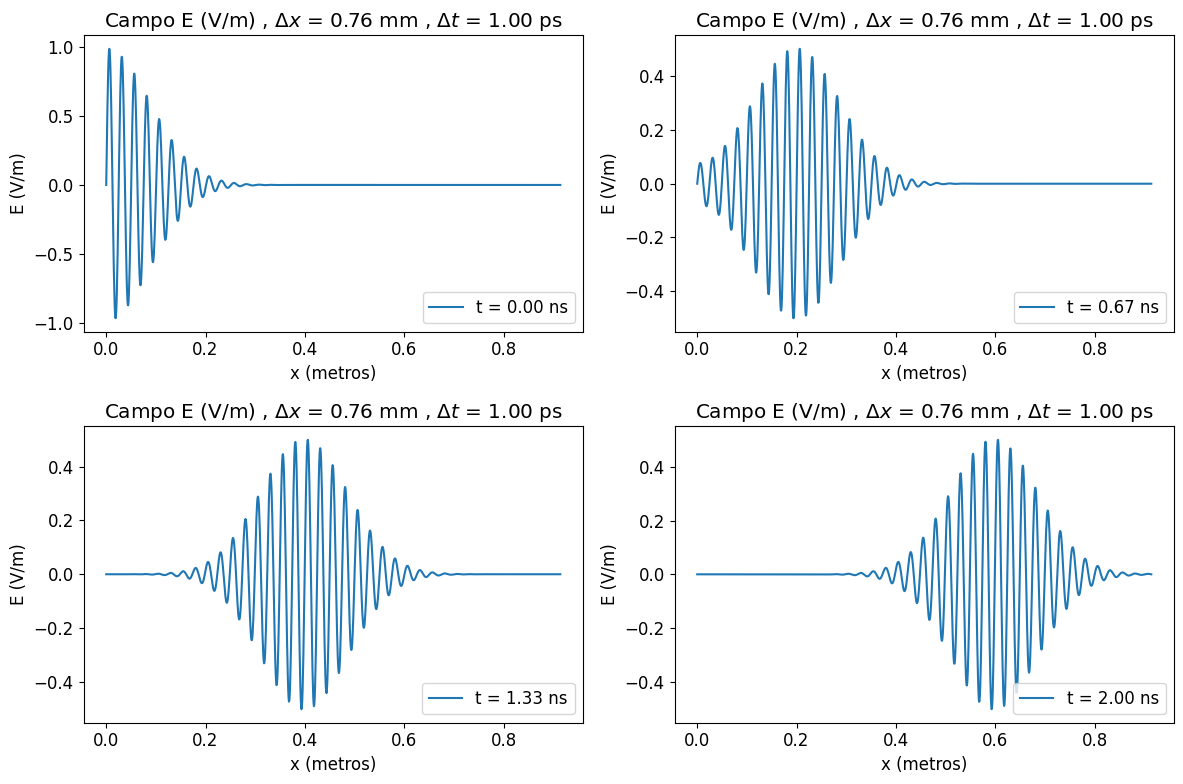

In [67]:
# plota as fotos
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for i, ax in enumerate(axes.flat):
    ax.plot(grid_xE, E_snapshots[i], label = fr't = {grid_tE[snapshot_times[i]] * 1e9:.2f} ns')
    ax.set_title(fr"Campo E (V/m) , $\Delta x$ = {dx * 1e3:.2f} mm , $\Delta t$ = {dt * 1e12:.2f} ps")
    ax.set_xlabel("x (metros)")
    ax.set_ylabel(f"E (V/m)")
    ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

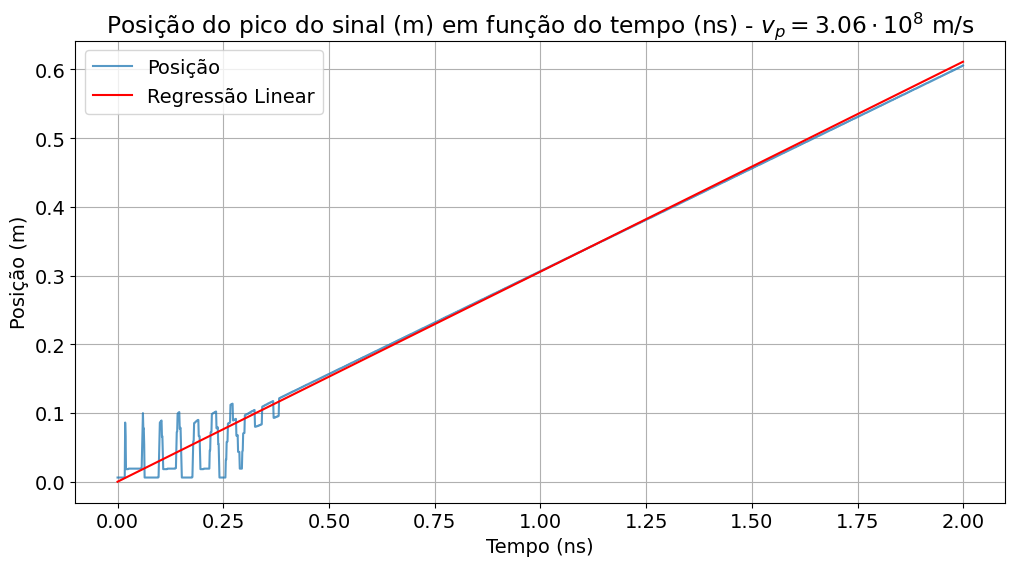

In [68]:
# plota a posicao do pico em função do tempo
slope, intercept = np.polyfit(grid_tE[:-1], posicao_pico, 1)

plt.figure(figsize=(12, 6))  # 10 inches wide, 5 inches tall
plt.rcParams.update({'font.size': 14}) 

plt.plot(grid_tE[:-1] * 1e9, posicao_pico, label="Posição", alpha=0.75)
plt.plot(grid_tE[:-1] * 1e9, slope * grid_tE[:-1], color="red", label="Regressão Linear")
plt.title(fr"Posição do pico do sinal (m) em função do tempo (ns) - $v_p = {slope / 1e8:.2f} \cdot 10^{8}$ m/s")
plt.xlabel("Tempo (ns)")
plt.ylabel("Posição (m)")
plt.grid()
plt.legend()